In [1]:
import lightkurve as lk
from lightkurve import search_lightcurve
import matplotlib.pyplot as plt
import requests
import pandas as pd
from time import perf_counter

%matplotlib inline


/opt/anaconda3/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
def queryMAST(KOI):
    """
    Use the MAST API to get info about the canonical name and KIC of a Kepler Object of Interest (KOI).
    Returns: JSON object with information about object with it's KIC as one of it's fields.
    """
    # Resolve KOI -> Kepler ID / canonical name using Exo.MAST
    info = requests.get(
        "https://exo.mast.stsci.edu/api/v0.1/exoplanets/identifiers/",
        params={"name": KOI},
        timeout=30,
    ).json()
    
    return info


In [3]:
def fetchStitchedLC(KIC):
    """
    Given a KIC, fetch it's light curve data using LC.
    Returns: Stitched LC object.
    """
    search = lk.search_lightcurve(
        f"KIC {KIC}",
        mission="Kepler",
        author="Kepler",
        cadence="long"
    )

    return search.download_all().stitch()


In [4]:
df = pd.read_csv(r"../assets/data/kepler-eclipsing-binary-catalog.csv")


In [5]:
df.head()


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC,Unnamed: 11
0,3863594,0.053268,0.0,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False,NaN
1,10417986,0.073731,0.0,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True,NaN
2,8912468,0.094838,0.0,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False,NaN
3,8758716,0.107205,0.0,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False,NaN
4,10855535,0.112782,0.0,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False,NaN


In [6]:
listOfKICs = df['KIC'].astype(int).tolist()


In [7]:
print(listOfKICs)


[3863594, 10417986, 8912468, 8758716, 10855535, 9472174, 9612468, 6613627, 5302006, 9898401, 7375612, 5872696, 7767774, 12350008, 10684673, 9532219, 6699679, 6287172, 11825204, 4921906, 6387887, 8288741, 12055255, 11013201, 8108785, 1572353, 10288502, 10453521, 9238207, 5166136, 8555795, 6144827, 10030943, 10965091, 2715417, 11413213, 9077796, 6050116, 12458797, 6350020, 7198474, 7546791, 7871200, 7959612, 3972629, 9345163, 8816790, 12216817, 11494583, 4738426, 8122124, 9032671, 5960283, 9412114, 9004380, 4857282, 12602985, 11336707, 12104285, 8367007, 11769739, 4138301, 9478836, 12508348, 5685072, 3839964, 12598713, 9700154, 9662581, 9777987, 2856960, 5611561, 7339345, 9288175, 9392331, 9239684, 12004834, 11284547, 8045121, 6106771, 10557008, 5785551, 9388303, 5773205, 2437038, 7269843, 6072578, 8028158, 2435971, 9026766, 10802917, 3832382, 7697065, 9760531, 5956588, 3743834, 9935311, 11704155, 2448320, 7335517, 8739802, 4385109, 4563150, 5104097, 9772642, 8624778, 7680593, 3853259, 1

In [8]:
len(listOfKICs)


2920

In [9]:
sample = listOfKICs[0]
lc = fetchStitchedLC(sample)
lc


time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
120.53895485026442,1.0027486e+00,9.6464049e-05,0,8.024303e-04,855.91043,470.81116,568,8.6757656e+04,8.6632309e+00,1.3368323e+03,4.5871329e-01,1.0105324e+05,9.7212849e+00,0,———,———,———,———,855.91043,1.0754935e-04,470.81116,1.0857590e-04,7.4910367e-04,6.0268366e-03
120.55938947320828,9.9671209e-01,9.7930511e-05,0,8.034532e-04,855.91046,470.81070,569,8.6349688e+04,8.6484098e+00,1.3367158e+03,4.5806941e-01,1.0044491e+05,9.8690701e+00,0,———,———,———,———,855.91046,1.0797208e-04,470.81070,1.0901532e-04,5.3021056e-04,5.4083508e-03
120.57982399609318,9.9942762e-01,9.8252800e-05,0,8.044761e-04,855.90958,470.81087,570,8.6580969e+04,8.6568336e+00,1.3375615e+03,4.5817694e-01,1.0071857e+05,9.9015484e+00,0,———,———,———,———,855.90958,1.0772468e-04,470.81087,1.0877372e-04,1.4986497e-04,5.5194623e-03
120.60025871903053,9.9980873e-01,9.7873060e-05,0,8.054990e-04,855.90939,470.81073,571,8.6605695e+04,8.6577063e+00,1.3352241e+03,4.5855182e-01,1.0075698e+05,9.8632803e+00,0,———,———,———,———,855.90939,1.0770949e-04,470.81073,1.0875158e-04,-6.4447266e-04,5.5453922e-03
120.6206933419162,9.9708158e-01,9.8207202e-05,0,8.065219e-04,855.90876,470.81095,572,8.6351383e+04,8.6484623e+00,1.3412815e+03,4.5779929e-01,1.0048214e+05,9.8969536e+00,0,———,———,———,———,855.90876,1.0795810e-04,470.81095,1.0902053e-04,-9.4780535e-04,5.2629397e-03
120.64112786480109,1.0019234e+00,9.7976932e-05,0,8.075448e-04,855.90843,470.81110,573,8.6743867e+04,8.6627750e+00,1.3368898e+03,4.5806941e-01,1.0097009e+05,9.8737478e+00,0,———,———,———,———,855.90843,1.0755685e-04,470.81110,1.0859519e-04,-1.5108449e-03,5.7550450e-03
120.66156248773768,9.9692065e-01,9.7949640e-05,0,8.085677e-04,855.90847,470.81070,574,8.6278812e+04,8.6457291e+00,1.3370372e+03,4.5856646e-01,1.0046592e+05,9.8709974e+00,0,———,———,———,———,855.90847,1.0803121e-04,470.81070,1.0908567e-04,-1.6055015e-03,5.2582524e-03
120.6819972105659,1.0019855e+00,9.8322860e-05,0,8.095906e-04,855.90859,470.81070,575,8.6687875e+04,8.6606560e+00,1.3338665e+03,4.5865881e-01,1.0097635e+05,9.9086094e+00,0,———,———,———,———,855.90859,1.0760132e-04,470.81070,1.0867089e-04,-1.5792947e-03,5.3304085e-03


In [10]:
type(lc)


lightkurve.lightcurve.KeplerLightCurve

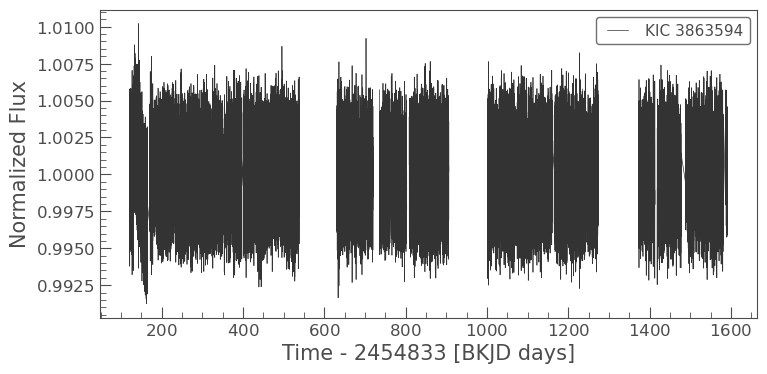

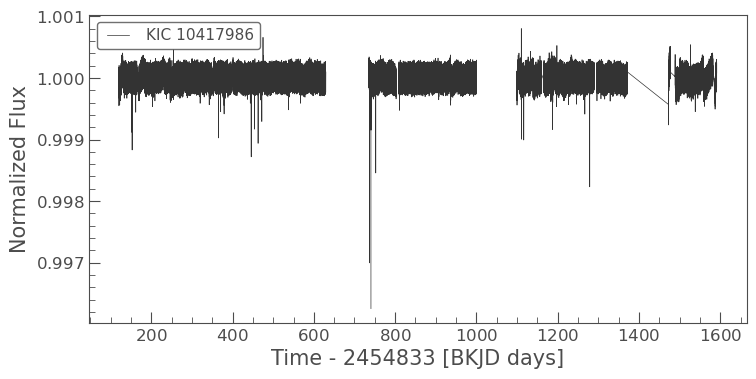

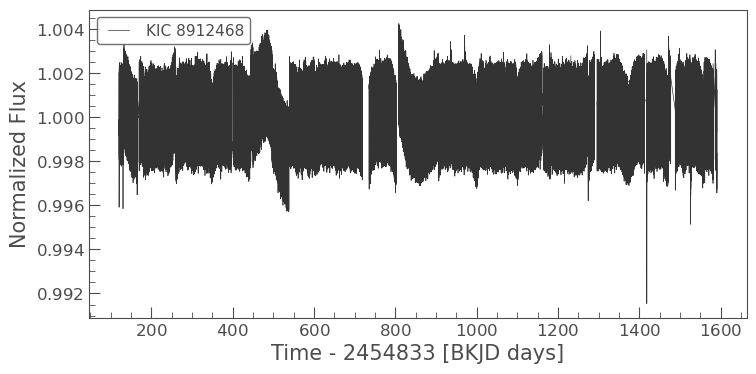

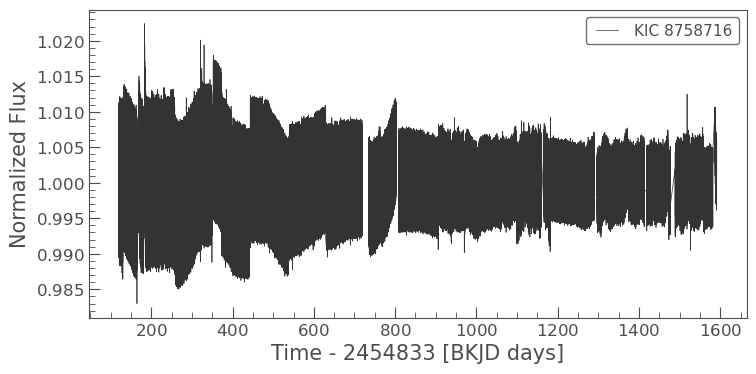

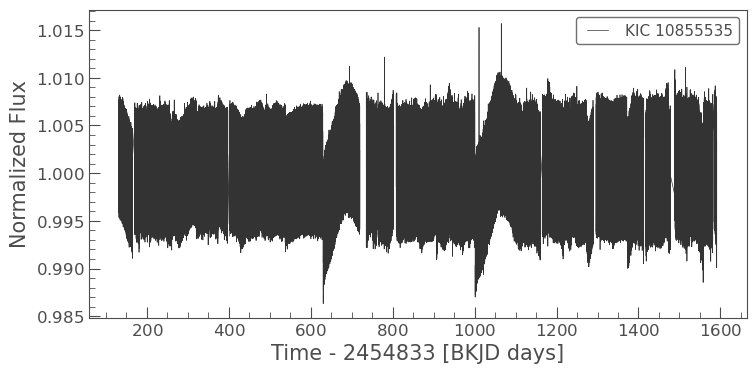

In [11]:
for i in range(5):
    start = perf_counter()
    KIC = listOfKICs[i]
    lc = fetchStitchedLC(KIC)
    end = perf_counter()
    
    lc.plot()


Test converting the lightcurve into arrays from being an LC object.

In [12]:
copyDf = df.head(3).copy()

In [13]:
def get_lc_arrays(kic):
    sr = search_lightcurve(f"KIC {kic}", mission="Kepler")
    lc = sr.download_all().stitch().remove_nans()
    
    return pd.Series({
        "time": lc.time.value,
        "flux": lc.flux.value,
        "flux_err": lc.flux_err.value if lc.flux_err is not None else None
    })

df[["time", "flux", "flux_err"]] = df["KIC"].apply(get_lc_arrays)

LightkurveError: Error in reading Data product /Users/wayfinder/.lightkurve/cache/mastDownload/Kepler/kplr009472174_sc_Q100003333333333332/kplr009472174-2010203174610_slc.fits of type KeplerLightCurve .
This file may be corrupt due to an interrupted download. Please remove it from your disk and try again.

In [ ]:
df